# Meta-AC Reversal ABC — Partial Readout + Configurable Weight Freezing

Trains `RNNActorCriticPartialReadout` on the 3-stimulus reversal task.
Only `readout_size` of the `hidden_size` recurrent neurons project to the actor/critic heads.

All analysis is run on **four populations**:
- **Full** — all `hidden_size` recurrent units
- **Projecting** — the `readout_size` neurons that feed actor/critic
- **Non-projecting** — the remaining neurons (no direct influence on policy/value)
- **Readout activations** — actor_fc + critic_fc outputs (3-dim: nolick_logit, lick_logit, value)

Plasticity can be selectively disabled via `FREEZE_MODE`.

In [57]:
%load_ext autoreload
%autoreload 2

import sys, torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from torch.optim import Adam
from collections import OrderedDict
from sklearn.decomposition import PCA
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, StratifiedKFold

sys.path.insert(0, str(Path("../").resolve()))
from cog_nn.tasks.reversal_envs import (
    ReversalABCMultiTimestepEnv,
    load_reversal_abc_multitimestep_data,
)
from cog_nn.models import RNNActorCriticPartialReadout
from cog_nn.agents import MetaA2CAgent
import cog_nn.plot_style

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [61]:
# ── Plasticity ─────────────────────────────────────────────────────────
# "none"         — all weights train
# "readout_only" — only actor_fc + critic_fc train; RNN (i2h + h2h) frozen
# "rnn_only"     — only RNN trains; actor_fc + critic_fc frozen
# "all"          — nothing trains
FREEZE_MODE = "none"

# ── Readout population ─────────────────────────────────────────────────
hidden_size   = 128
USE_PARTIAL_READOUT = False    # False = all neurons project (full readout)
READOUT_SIZE  = hidden_size // 2 if USE_PARTIAL_READOUT else hidden_size

# ── Hyper-parameters ───────────────────────────────────────────────────
learning_rate     = 0.0005
gamma             = 0
policy_clip_param = 0.25

# ── Paths ──────────────────────────────────────────────────────────────
_ro_str        = f"partialro{READOUT_SIZE}" if USE_PARTIAL_READOUT else "fullro"
save_path      = Path(f"/Users/pmccarthy/Documents/modelling_results/feb_2026_metarl_representations/"
                      f"reversal_abc_{_ro_str}_frozen{FREEZE_MODE}")
task_data_path = Path("/Users/pmccarthy/Documents/cogNN/task_data")
task           = "reversal_abc_multitimestep"

assert FREEZE_MODE in ("none", "readout_only", "rnn_only", "all"),     f"Unknown FREEZE_MODE '{FREEZE_MODE}'"

save_path.mkdir(parents=True, exist_ok=True)
print(f"FREEZE_MODE={FREEZE_MODE!r}   READOUT_SIZE={READOUT_SIZE}/{hidden_size}")

_freeze_labels = {
    "none":         "full plasticity",
    "readout_only": "readout plasticity only",
    "rnn_only":     "RNN plasticity only",
    "all":          "frozen weights",
}
freeze_label = _freeze_labels[FREEZE_MODE]
print(f"Freeze label: {freeze_label}")


FREEZE_MODE='none'   READOUT_SIZE=128/128
Freeze label: full plasticity


---
## Load task data

In [43]:
data_path = task_data_path / f"{task}.pkl"
(
    state_sequence, reward_sequence, reversal_mask,
    phase_boundaries, trial_structure, state_map
) = load_reversal_abc_multitimestep_data(data_path)

print(f"State sequence shape: {state_sequence.shape}")
print(f"Total timesteps:      {len(state_sequence)}")
print(f"Reversal point:       {phase_boundaries['reversal_points'][0]}")

State sequence shape: (561124, 7)
Total timesteps:      561124
Reversal point:       280420


In [44]:
env = ReversalABCMultiTimestepEnv(
    state_sequence, reward_sequence, reversal_mask, trial_structure,
    reward_lick=1.0, lick_no_reward=-1.0, no_lick=0.0
)
state_size  = env.observation_space.shape[0]
action_size = env.action_space.n
print(f"state_size={state_size}, action_size={action_size}")

state_size=7, action_size=2


---
## Model configuration

In [45]:
readout_indices     = list(range(READOUT_SIZE))
non_readout_indices = list(range(READOUT_SIZE, hidden_size))
# When USE_PARTIAL_READOUT=False, READOUT_SIZE==hidden_size so non_readout_indices=[]

model = RNNActorCriticPartialReadout(
    state_size=state_size,
    action_size=action_size,
    hidden_size=hidden_size,
    readout_indices=readout_indices,
)

# ── Apply freezing ─────────────────────────────────────────────────────
if FREEZE_MODE == "readout_only":
    for name, param in model.named_parameters():
        param.requires_grad = name.startswith("actor_fc") or name.startswith("critic_fc")
    trainable = [p for p in model.parameters() if p.requires_grad]
    model.optimizer = Adam(trainable, lr=learning_rate)
    print("Frozen: RNN (rnn.*).  Trainable: actor_fc, critic_fc.")

elif FREEZE_MODE == "rnn_only":
    for name, param in model.named_parameters():
        param.requires_grad = name.startswith("rnn")
    trainable = [p for p in model.parameters() if p.requires_grad]
    model.optimizer = Adam(trainable, lr=learning_rate)
    print("Frozen: actor_fc, critic_fc.  Trainable: RNN (rnn.*).")

elif FREEZE_MODE == "all":
    for param in model.parameters():
        param.requires_grad = False
    model.optimizer = Adam([], lr=learning_rate)
    print("All weights frozen.")

else:  # "none"
    model.optimizer = Adam(model.parameters(), lr=learning_rate)
    print("All weights trainable.")

model.gamma = gamma

agent = MetaA2CAgent(state_size=state_size, action_size=action_size, hidden_size=hidden_size)
agent.model = model

n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
n_total     = sum(p.numel() for p in model.parameters())
print(f"Projecting: {len(readout_indices)} neurons (indices 0–{READOUT_SIZE-1})")
print(f"Non-proj:   {len(non_readout_indices)} neurons (indices {READOUT_SIZE}–{hidden_size-1})")
print(f"Trainable params: {n_trainable:,} / {n_total:,}")

All weights trainable.
Projecting: 128 neurons (indices 0–127)
Non-proj:   0 neurons (indices 128–127)
Trainable params: 18,307 / 18,307


---
## Metrics dictionary

In [46]:
stim_keys   = ['A', 'B', 'C']
idx_to_stim = {0: 'A', 1: 'B', 2: 'C'}

metrics = {
    'lick_probs':  {k: [] for k in stim_keys},
    'values':      {k: [] for k in stim_keys},
    'timesteps':   {k: [] for k in stim_keys},

    'trial_lick_probs':      {k: [] for k in stim_keys},
    'trial_values':          {k: [] for k in stim_keys},
    'trial_timesteps':       [],
    'trial_indices':         [],
    'trial_reversal_phases': [],

    'trial_boundaries':        [],
    'within_trial_lick_probs': {},
    'within_trial_values':     {},
    'within_trial_timesteps':  {},
    'within_trial_states':     {},
    'hidden_states':           {},   # full hidden_size-d per timestep

    'rewards':          [],
    'reward_timesteps': [],
}

---
## Training

In [47]:
pre_start,  pre_end  = 0, phase_boundaries['pre_reversal']['end']
post_start, post_end = phase_boundaries['post_reversal']['start'], phase_boundaries['post_reversal']['end']
batch_size = 1

agent.model.train()
agent.reset_hidden_state()

obs, info = env.reset()
prev_action = torch.zeros(action_size)
prev_reward = torch.tensor(0.0)

states_batch, prev_actions_batch, prev_rewards_batch = [], [], []
actions_batch, rewards_batch = [], []
next_states_batch, dones_batch = [], []
next_prev_actions_batch, next_prev_rewards_batch = [], []


def record_step(t_idx, obs, action, action_prob, value, rnn_out, reward, info):
    state_idx  = int(np.argmax(obs))
    trial_info = info.get('trial_idx')
    lick_p     = action_prob if action == 0 else (1.0 - action_prob)

    if state_idx in idx_to_stim:
        k = idx_to_stim[state_idx]
        metrics['lick_probs'][k].append(lick_p)
        metrics['values'][k].append(float(value))
        metrics['timesteps'][k].append(t_idx)

    if trial_info is not None:
        td = trial_structure[trial_info]
        if t_idx == td['trial_start']:
            metrics['trial_boundaries'].append({
                'trial_idx':        trial_info,
                'trial_start':      td['trial_start'],
                'trial_end':        td['trial_end'],
                'stimulus':         td['stimulus'],
                'reversal_phase':   td['reversal_phase'],
                'reward_available': td['reward_available'],
            })
            metrics['within_trial_lick_probs'][trial_info] = []
            metrics['within_trial_values'][trial_info]     = []
            metrics['within_trial_timesteps'][trial_info]  = []
            metrics['within_trial_states'][trial_info]     = []
            metrics['hidden_states'][trial_info]           = []

        if trial_info in metrics['within_trial_lick_probs']:
            metrics['within_trial_lick_probs'][trial_info].append(lick_p)
            metrics['within_trial_values'][trial_info].append(float(value))
            metrics['within_trial_timesteps'][trial_info].append(t_idx)
            metrics['within_trial_states'][trial_info].append(info.get('state_name', 'unknown'))
            metrics['hidden_states'][trial_info].append(rnn_out.cpu().numpy())  # full hidden_size-d

        if t_idx == td['stim_window'][-1]:
            k = idx_to_stim.get(td['stimulus'])
            if k:
                metrics['trial_lick_probs'][k].append(lick_p)
                metrics['trial_values'][k].append(float(value))
            metrics['trial_timesteps'].append(t_idx)
            metrics['trial_indices'].append(trial_info)
            metrics['trial_reversal_phases'].append(td['reversal_phase'])

    if info.get('reward_available', False):
        metrics['rewards'].append(reward)
        metrics['reward_timesteps'].append(t_idx)


print(f"Training (FREEZE_MODE='{FREEZE_MODE}')...")
for t_idx in range(pre_start, post_end):
    state = torch.from_numpy(obs).float()

    action, action_prob, value, rnn_out = agent.select_action(
        state, prev_action, prev_reward,
        deterministic=False, policy_clip=policy_clip_param, return_rnn_out=True
    )

    next_obs, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated

    record_step(t_idx, obs, action, action_prob, value, rnn_out, reward, info)

    next_prev_action = torch.zeros(action_size)
    next_prev_action[action] = 1.0

    if FREEZE_MODE != "all":
        states_batch.append(obs)
        prev_actions_batch.append(prev_action.numpy())
        prev_rewards_batch.append(prev_reward.item())
        actions_batch.append(action)
        rewards_batch.append(reward)
        next_states_batch.append(next_obs)
        next_prev_actions_batch.append(next_prev_action.numpy())
        next_prev_rewards_batch.append(reward)
        dones_batch.append(done)

        if len(states_batch) >= batch_size:
            agent.update(
                torch.from_numpy(np.array(states_batch)).float(),
                torch.from_numpy(np.array(prev_actions_batch)).float(),
                torch.from_numpy(np.array(prev_rewards_batch)).float(),
                torch.from_numpy(np.array(actions_batch)).long(),
                torch.from_numpy(np.array(rewards_batch)).float(),
                torch.from_numpy(np.array(next_states_batch)).float(),
                torch.from_numpy(np.array(next_prev_actions_batch)).float(),
                torch.from_numpy(np.array(next_prev_rewards_batch)).float(),
                torch.from_numpy(np.array(dones_batch)).float()
            )
            states_batch, prev_actions_batch, prev_rewards_batch = [], [], []
            actions_batch, rewards_batch = [], []
            next_states_batch, dones_batch = [], []
            next_prev_actions_batch, next_prev_rewards_batch = [], []

    obs         = next_obs
    prev_action = next_prev_action
    prev_reward = torch.tensor(reward, dtype=torch.float32)

    if t_idx % 50000 == 0:
        print(f"  timestep {t_idx}/{post_end}")

print("Training complete.")

Training (FREEZE_MODE='none')...
  timestep 0/561124
  timestep 50000/561124
  timestep 100000/561124
  timestep 150000/561124
  timestep 200000/561124
  timestep 250000/561124
  timestep 300000/561124
  timestep 350000/561124
  timestep 400000/561124
  timestep 450000/561124
  timestep 500000/561124
  timestep 550000/561124
Training complete.


---
## Save model and metrics

In [48]:
metrics_numpy = {
    'lick_probs':  {k: np.array(v) for k, v in metrics['lick_probs'].items()},
    'values':      {k: np.array(v) for k, v in metrics['values'].items()},
    'timesteps':   {k: np.array(v) for k, v in metrics['timesteps'].items()},
    'trial_lick_probs': {k: np.array(v) for k, v in metrics['trial_lick_probs'].items()},
    'trial_values':     {k: np.array(v) for k, v in metrics['trial_values'].items()},
    'trial_timesteps':       np.array(metrics['trial_timesteps']),
    'trial_indices':         np.array(metrics['trial_indices']),
    'trial_reversal_phases': np.array(metrics['trial_reversal_phases']),
    'trial_boundaries':        metrics['trial_boundaries'],
    'within_trial_lick_probs': metrics['within_trial_lick_probs'],
    'within_trial_values':     metrics['within_trial_values'],
    'within_trial_timesteps':  metrics['within_trial_timesteps'],
    'within_trial_states':     metrics['within_trial_states'],
    'hidden_states':           metrics['hidden_states'],
    'rewards':          np.array(metrics['rewards']),
    'reward_timesteps': np.array(metrics['reward_timesteps']),
}
torch.save(model.state_dict(), save_path / "model.pth")
print(f"Saved to {save_path}")

Saved to /Users/pmccarthy/Documents/modelling_results/reversal_abc_fullro_frozennone


---
## Lick probability and value over trials

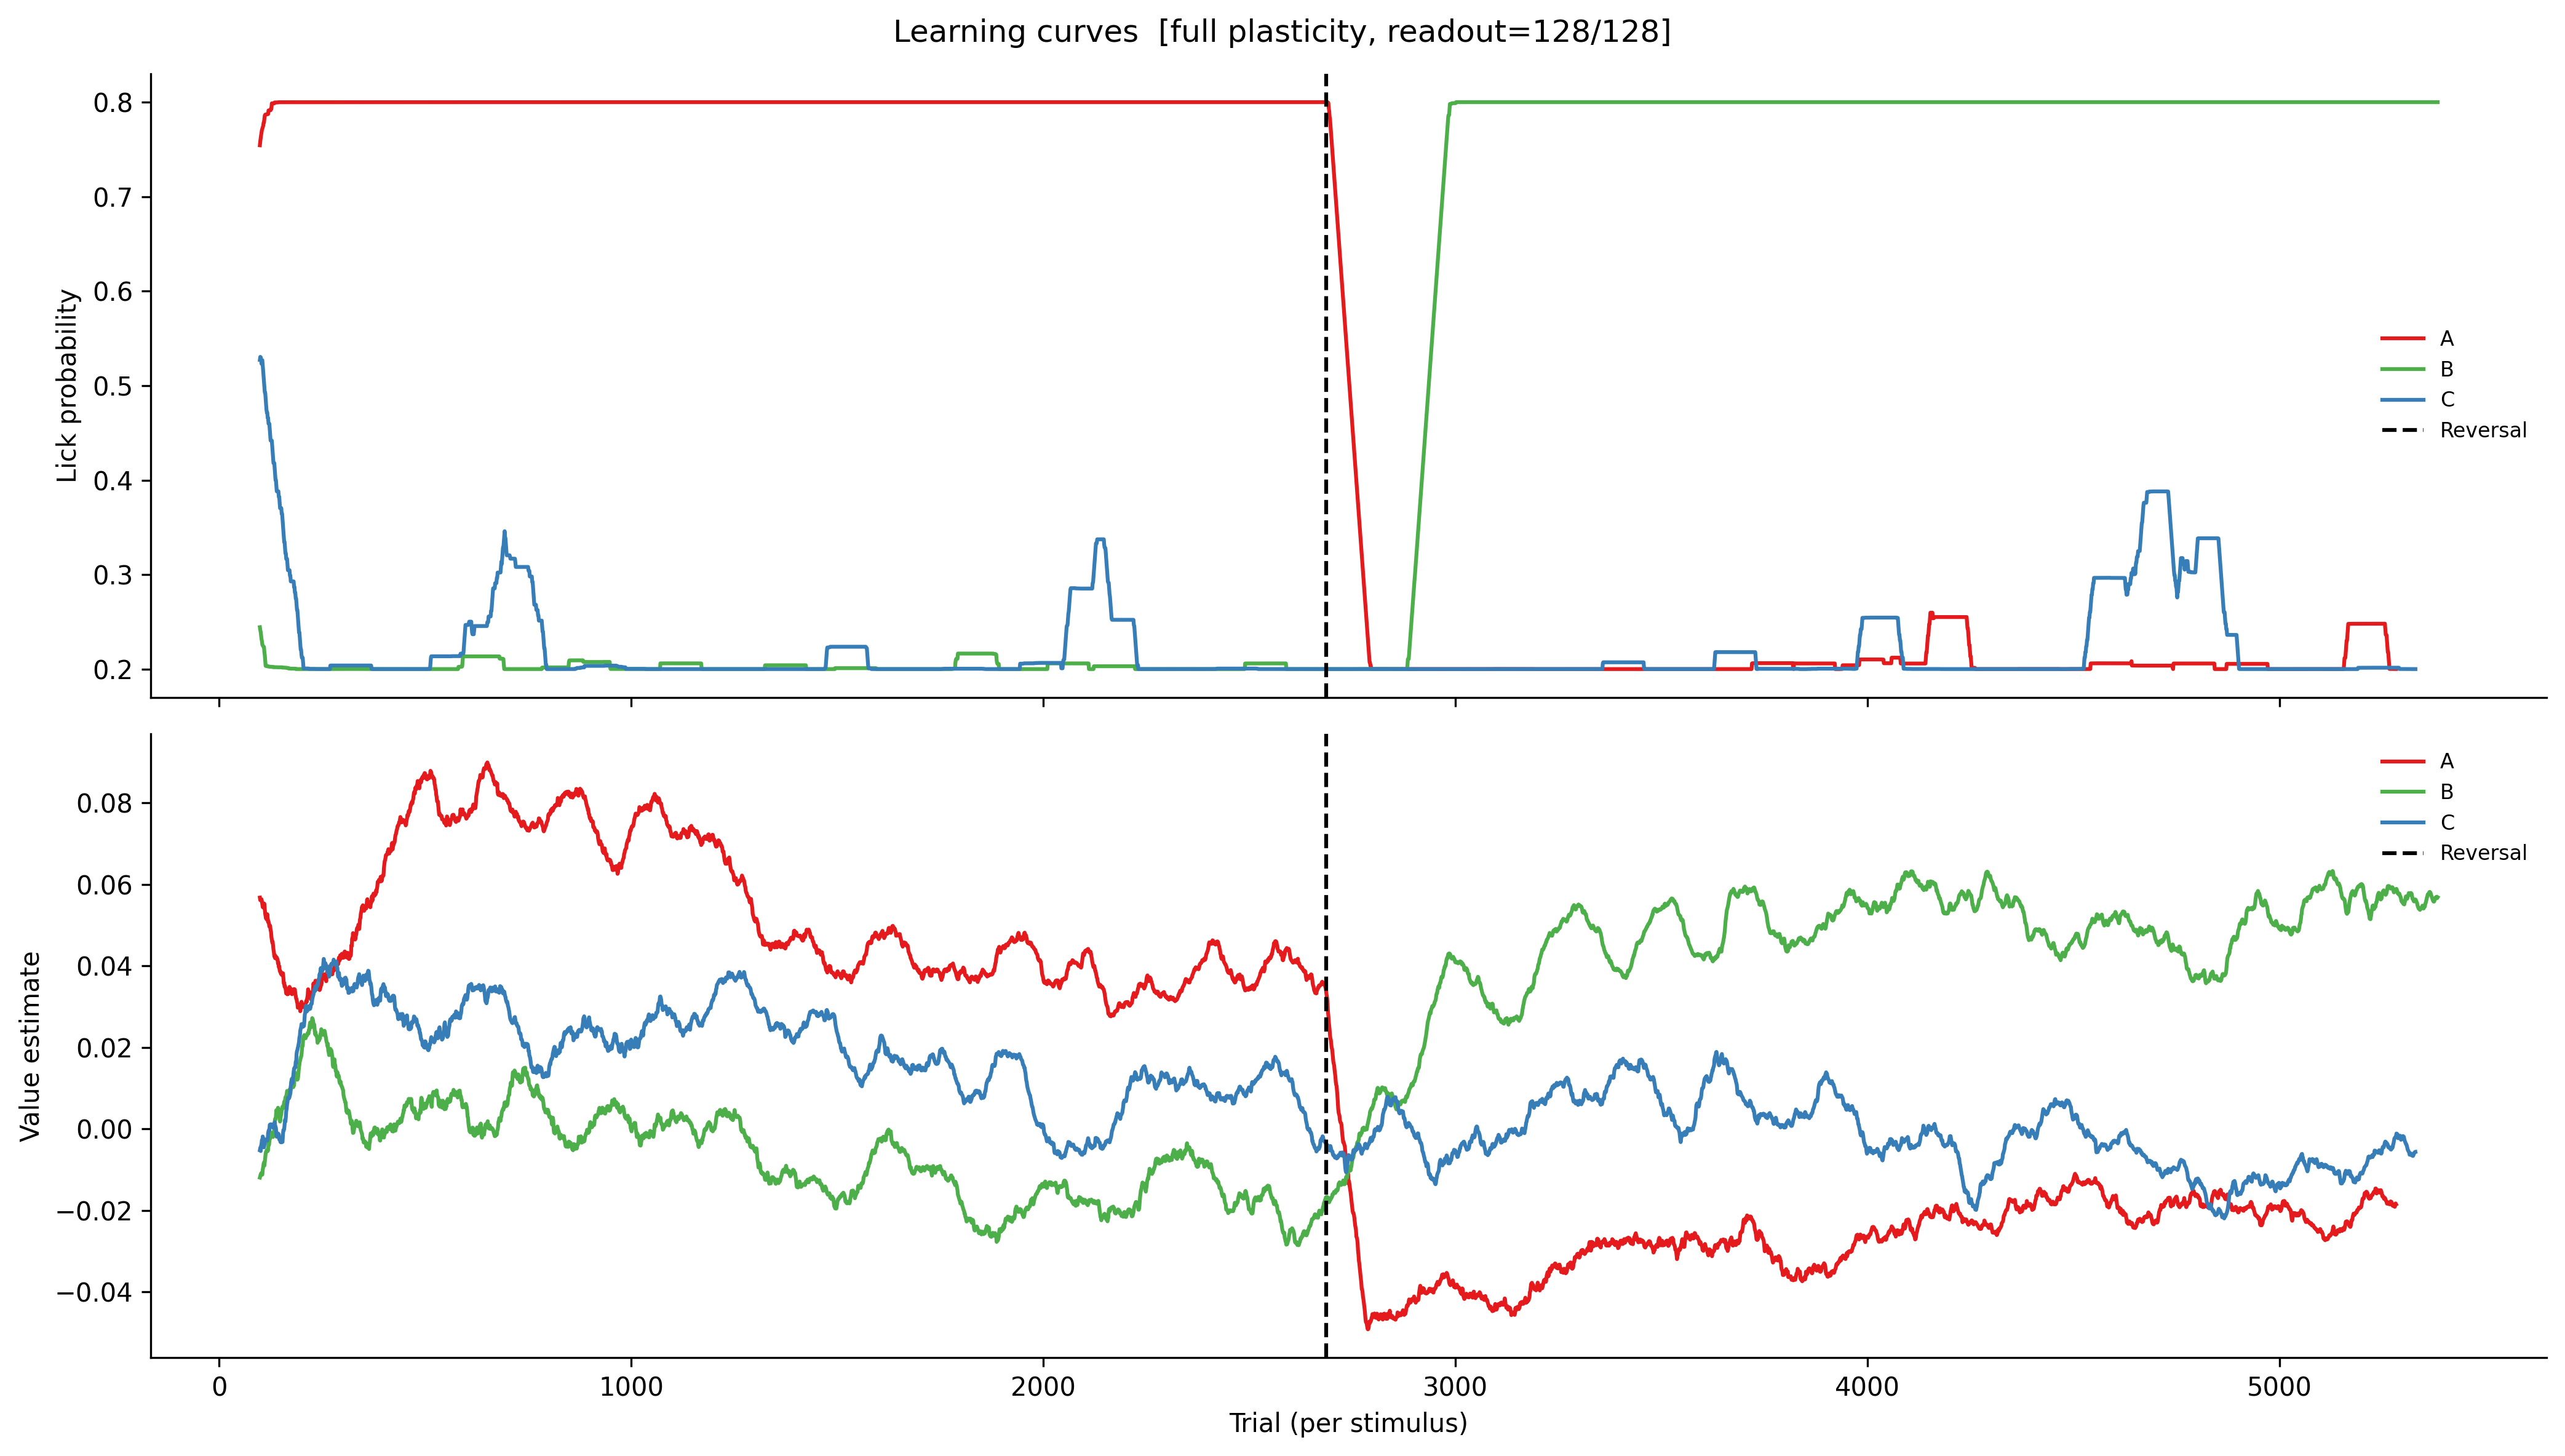

In [63]:
colors = {'A': '#e41a1c', 'B': '#4daf4a', 'C': '#377eb8'}
smooth = 100

# Reversal index on the per-stim x-axis.
# Each stimulus is presented equally often, so all three have the same
# number of pre-reversal trials → a single reversal index suffices.
rev_idx = sum(1 for tb in metrics_numpy['trial_boundaries']
              if tb['stimulus'] == 0 and tb['reversal_phase'] == 0)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
for k in stim_keys:
    lp = metrics_numpy['trial_lick_probs'][k]
    vl = metrics_numpy['trial_values'][k]
    x  = np.arange(len(lp))
    if len(lp) > smooth:
        axes[0].plot(x[smooth-1:], np.convolve(lp, np.ones(smooth)/smooth, mode='valid'),
                     color=colors[k], label=k, lw=1.5)
        axes[1].plot(x[smooth-1:], np.convolve(vl, np.ones(smooth)/smooth, mode='valid'),
                     color=colors[k], label=k, lw=1.5)
    else:
        axes[0].plot(x, lp, color=colors[k], label=k, lw=1.5)
        axes[1].plot(x, vl, color=colors[k], label=k, lw=1.5)

for ax in axes:
    ax.axvline(rev_idx, color='k', linestyle='--', lw=1.5, label='Reversal')
    ax.legend(fontsize=8)

axes[0].set_ylabel('Lick probability')
axes[1].set_ylabel('Value estimate')
axes[1].set_xlabel('Trial (per stimulus)')
plt.suptitle(f'Learning curves  [{freeze_label}, readout={READOUT_SIZE}/{hidden_size}]')
plt.tight_layout(); fig.savefig(save_path / "learning_curves.png", dpi=300, bbox_inches='tight'); plt.show()
fig.savefig(save_path / "learning_curves.png", dpi=300, bbox_inches='tight')

In [60]:
save_path

PosixPath('/Users/pmccarthy/Documents/modelling_results/feb_2026_metarl_representationsreversal_abc_fullro_frozennone')

---
## Population Analysis

Builds trial-averaged stim-window activations for all four populations, fits PCA for each, and defines a shared `populations` dictionary used by all subsequent analysis cells.

In [50]:
# ── Build stim-window-averaged hidden states ───────────────────────────
all_activations = []
all_stim_labels  = []
all_phase_labels = []

for tb in metrics_numpy['trial_boundaries']:
    ti = tb['trial_idx']
    if ti not in metrics_numpy['hidden_states']:
        continue
    t_info  = trial_structure[ti]
    hs_list = metrics_numpy['hidden_states'][ti]
    wt_ts   = np.array(metrics_numpy['within_trial_timesteps'][ti])
    t_start = t_info['trial_start']

    stim_rel = np.array(t_info['stim_window']) - t_start
    wt_rel   = wt_ts - t_start
    activs   = []
    for tr in stim_rel:
        m = np.where(wt_rel == tr)[0]
        if len(m) > 0 and m[0] < len(hs_list):
            activs.append(hs_list[m[0]])
    if not activs:
        continue
    all_activations.append(np.mean(activs, axis=0).squeeze())
    all_stim_labels.append(t_info['stimulus'])
    all_phase_labels.append(t_info['reversal_phase'])

all_activations  = np.array(all_activations)   # (n_trials, hidden_size)
all_stim_labels  = np.array(all_stim_labels)
all_phase_labels = np.array(all_phase_labels)

act_proj    = all_activations[:, readout_indices]       # (n_trials, READOUT_SIZE)

# ── Readout activations ────────────────────────────────────────────────
# actor_fc receives readout_size-dim input (not full hidden_size)
W_actor  = model.actor_fc.weight.detach().numpy()   # (2, READOUT_SIZE)
b_actor  = model.actor_fc.bias.detach().numpy()
W_critic = model.critic_fc.weight.detach().numpy()  # (1, READOUT_SIZE)
b_critic = model.critic_fc.bias.detach().numpy()

actor_logits  = act_proj @ W_actor.T  + b_actor   # (n_trials, 2)
critic_values = act_proj @ W_critic.T + b_critic  # (n_trials, 1)
readout_all   = np.hstack([actor_logits, critic_values])  # (n_trials, 3)
readout_dim_labels = ['nolick_logit', 'lick_logit', 'value']

# ── Populations dict ───────────────────────────────────────────────────
populations = OrderedDict()
populations['Full']       = all_activations
populations['Projecting'] = act_proj
if non_readout_indices:
    act_nonproj = all_activations[:, non_readout_indices]
    populations['Non-proj'] = act_nonproj
populations['Readout act'] = readout_all
pop_colors = {'Full': '#444444', 'Projecting': '#1f77b4',
              'Non-proj': '#d62728', 'Readout act': '#2ca02c'}

# ── Fit PCA per population ─────────────────────────────────────────────
pcas  = {}
projs = {}
n_pca_components = 2
for name, acts in populations.items():
    n_comp = min(n_pca_components, acts.shape[1])
    pca_obj = PCA(n_components=n_comp).fit(acts)
    pcas[name]  = pca_obj
    projs[name] = pca_obj.transform(acts)

print(f"all_activations : {all_activations.shape}")
print(f"act_proj        : {act_proj.shape}")
print(f"act_nonproj     : {act_nonproj.shape}")
print(f"readout_all     : {readout_all.shape}")
for name, pca_obj in pcas.items():
    ev = pca_obj.explained_variance_ratio_
    print(f"  PCA [{name}]: PC1={ev[0]*100:.1f}%  PC2={ev[1]*100:.1f}%  total={ev.sum()*100:.1f}%")

all_activations : (16000, 128)
act_proj        : (16000, 128)
act_nonproj     : (16000, 64)
readout_all     : (16000, 3)
  PCA [Full]: PC1=52.0%  PC2=18.5%  total=70.5%
  PCA [Projecting]: PC1=52.0%  PC2=18.5%  total=70.5%
  PCA [Readout act]: PC1=100.0%  PC2=0.0%  total=100.0%


---
## PCA — stimulus identity and reversal phase

In [ ]:
import matplotlib.colors as mc

def lighten_color(hex_color, amount=0.55):
    """Blend hex_color toward white (amount=0 → original, amount=1 → white)."""
    c = np.array(mc.to_rgb(hex_color))
    return tuple(c + amount * (np.ones(3) - c))

stim_colors_dark  = {0: '#e41a1c', 1: '#4daf4a', 2: '#377eb8'}   # post (full)
stim_colors_light = {k: lighten_color(v) for k, v in stim_colors_dark.items()}  # pre (pale)
phase_color_map   = {0: stim_colors_light, 1: stim_colors_dark}
phase_markers     = {0: 'o', 1: 's'}   # used by trial-evolution cell

stim_names_map    = {0: 'A', 1: 'B', 2: 'C'}
SHOW_CENTROID_ARROWS = True   # set False to hide reversal-movement arrows

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, (name, proj) in zip(axes, projs.items()):
    pca_obj = pcas[name]
    ev = pca_obj.explained_variance_ratio_

    # ── scatter points ─────────────────────────────────────────────────
    for s in range(3):
        for phase in [0, 1]:
            mask = (all_stim_labels == s) & (all_phase_labels == phase)
            if not mask.any():
                continue
            color = phase_color_map[phase][s]
            lbl   = f"{stim_names_map[s]} {'(pre)' if phase == 0 else '(post)'}"
            ax.scatter(proj[mask, 0], proj[mask, 1],
                       color=color, marker='o', alpha=0.4, s=8,
                       label=lbl, rasterized=True)

    # ── centroids ──────────────────────────────────────────────────────
    centroids = {}
    for s in range(3):
        for phase in [0, 1]:
            mask = (all_stim_labels == s) & (all_phase_labels == phase)
            if mask.any():
                c = proj[mask, :2].mean(axis=0)
                centroids[(s, phase)] = c
                color = phase_color_map[phase][s]
                ax.scatter(*c, color=color, s=100, marker='o',
                           edgecolors='black', linewidths=1.5, zorder=5)

    # ── arrows: pre centroid → post centroid ───────────────────────────
    if SHOW_CENTROID_ARROWS:
        for s in range(3):
            if (s, 0) in centroids and (s, 1) in centroids:
                c0, c1 = centroids[(s, 0)], centroids[(s, 1)]
                ax.annotate('', xy=c1, xytext=c0,
                            arrowprops=dict(arrowstyle='-|>', lw=2,
                                            color=stim_colors_light[s],
                                            mutation_scale=20))

    ax.set_xlabel(f'PC1 ({ev[0]*100:.1f}%)')
    ax.set_ylabel(f'PC2 ({ev[1]*100:.1f}%)')
    ax.set_title(name)
    handles, labels_leg = ax.get_legend_handles_labels()
    ax.legend(dict(zip(labels_leg, handles)).values(),
              dict(zip(labels_leg, handles)).keys(), fontsize=7)

plt.suptitle(f'PCA — stimulus identity + phase  [{freeze_label}]\n'
             'Pale = pre-reversal,  saturated = post-reversal,  ● = centroid,  → = reversal shift')
plt.tight_layout(); fig.savefig(save_path / "pca_stim_phase.png", dpi=300, bbox_inches='tight'); plt.show()

---
## PCA — trial-by-trial evolution

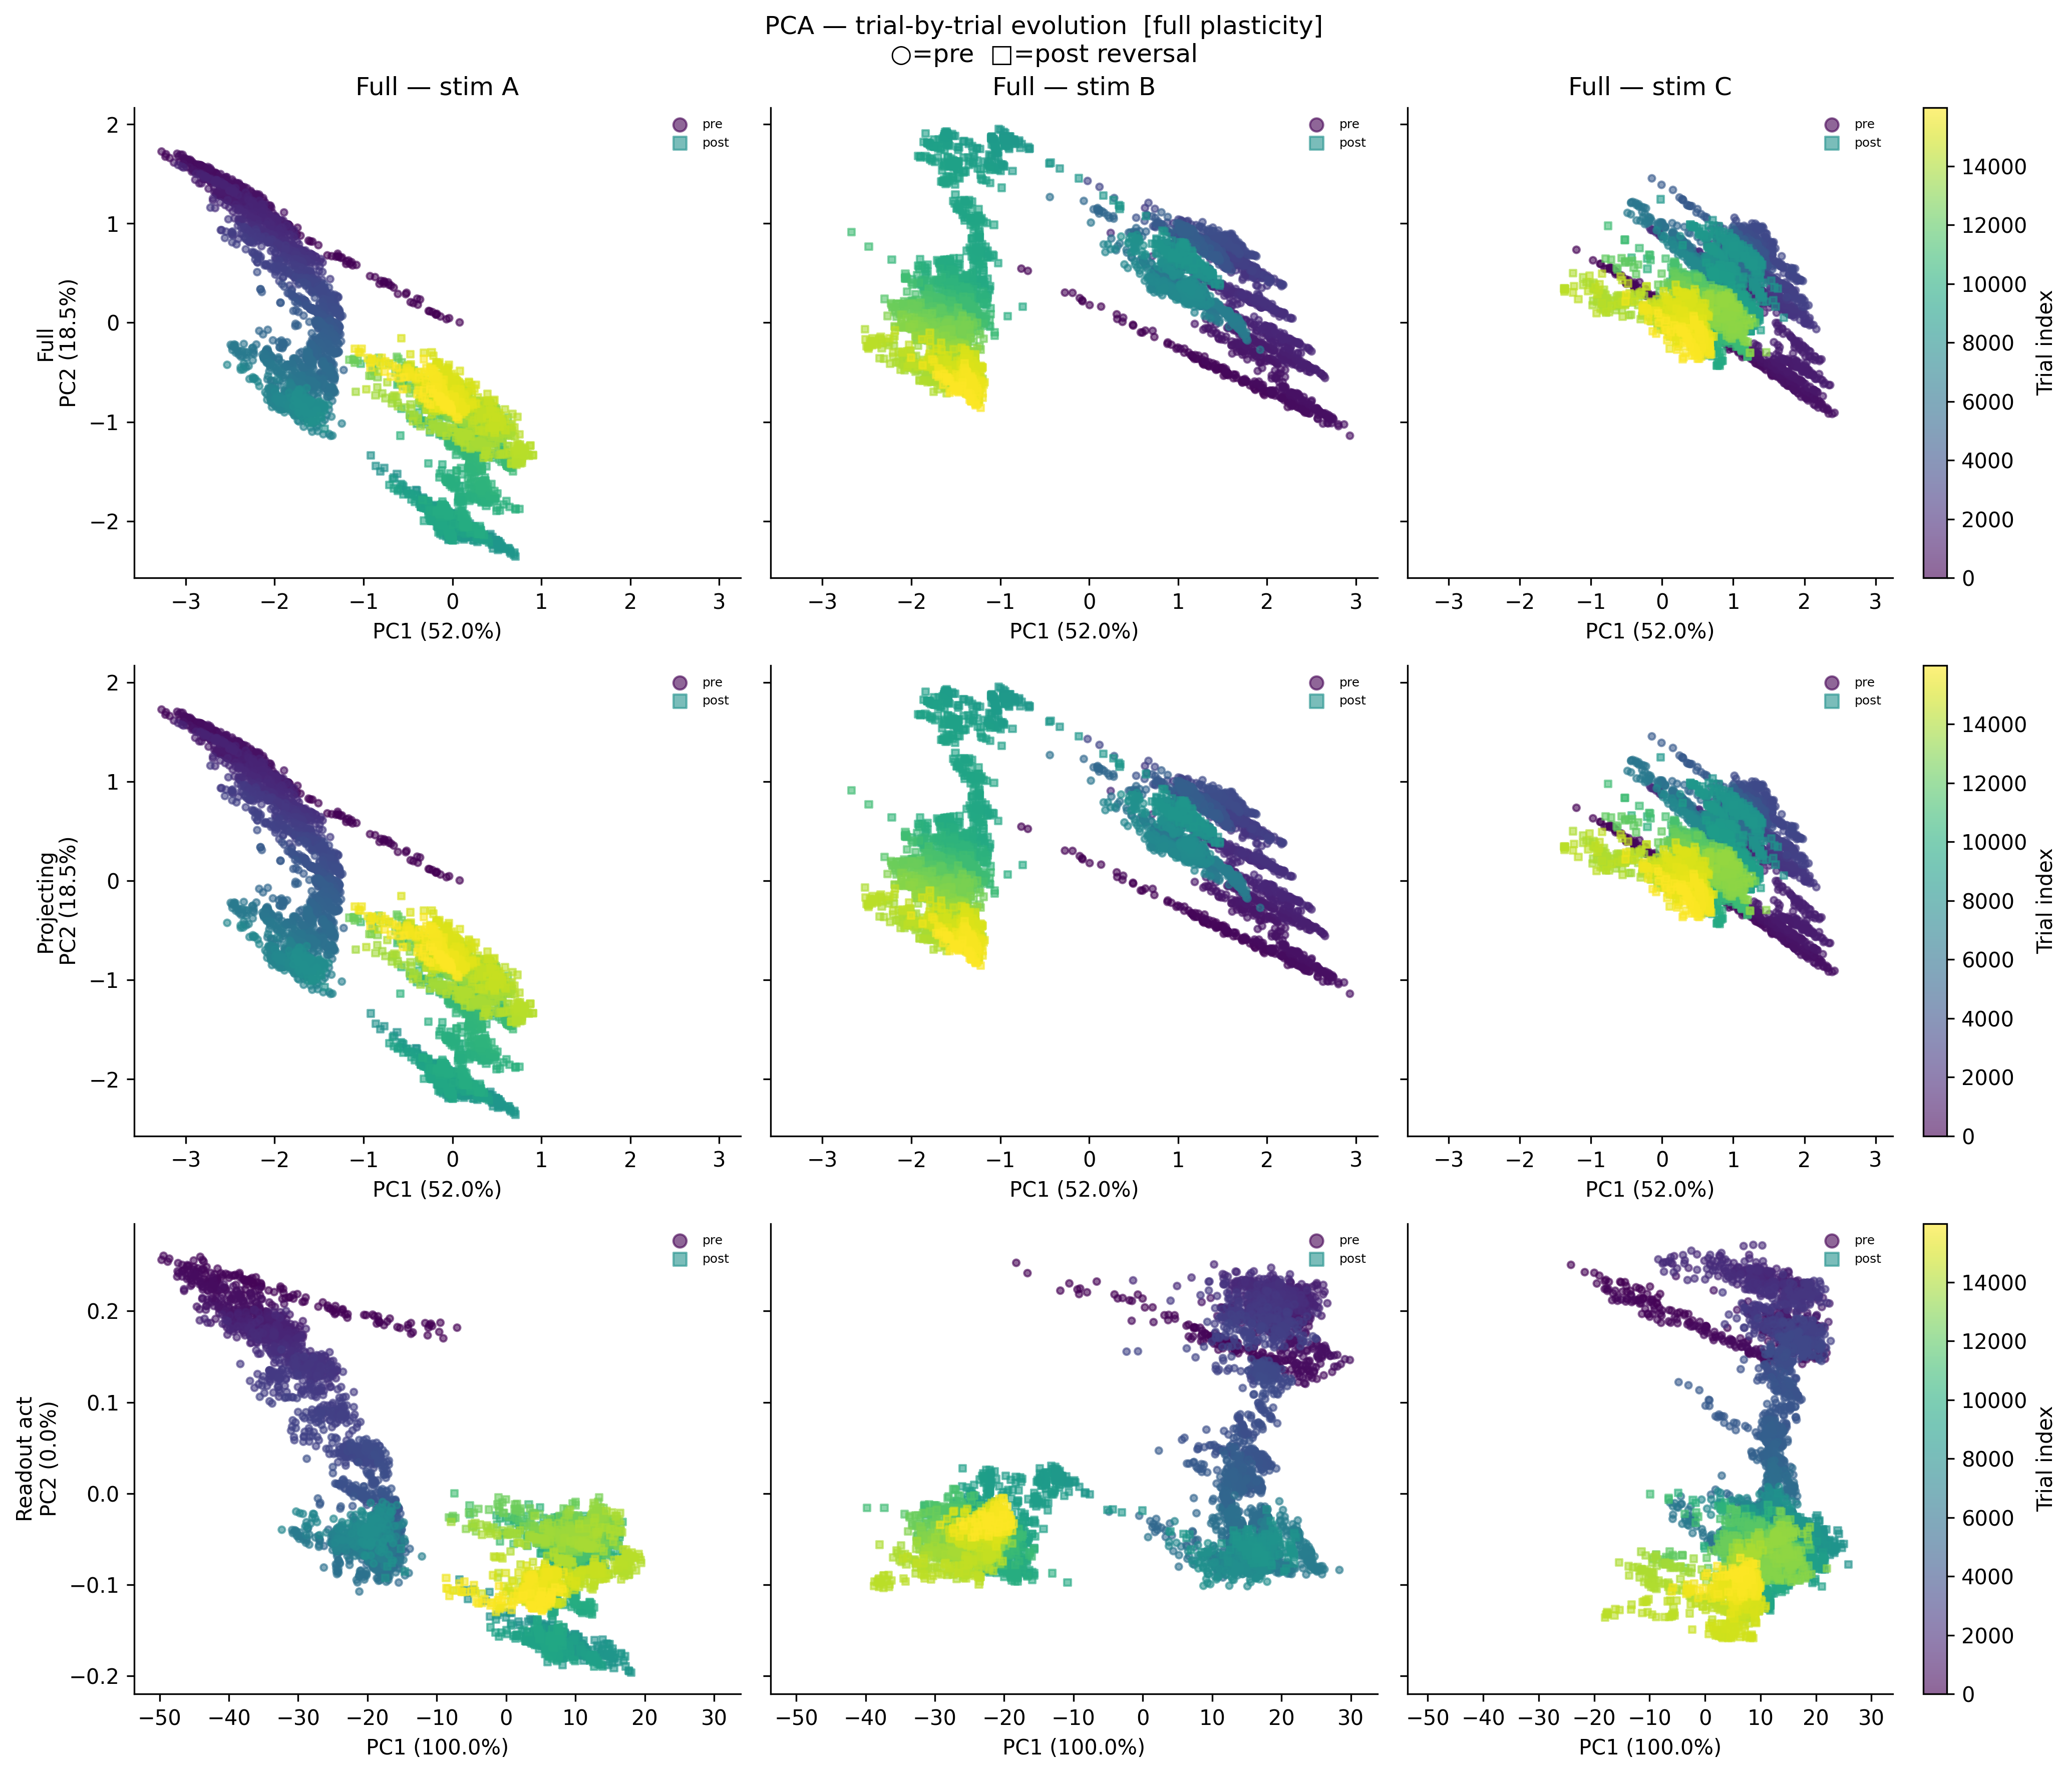

In [52]:
all_trial_indices = np.arange(len(all_activations))
phase_markers = {0: 'o', 1: 's'}   # circle = pre, square = post
n_pops = len(populations)

fig, axes = plt.subplots(n_pops, 3, figsize=(14, 4 * n_pops), sharey='row', sharex='row')

for row, (name, proj) in enumerate(projs.items()):
    pca_obj = pcas[name]
    ev = pca_obj.explained_variance_ratio_
    sc = None
    for col, s in enumerate(range(3)):
        ax = axes[row, col]
        for phase in [0, 1]:
            mask = (all_stim_labels == s) & (all_phase_labels == phase)
            if not mask.any():
                continue
            sc = ax.scatter(proj[mask, 0], proj[mask, 1],
                            c=all_trial_indices[mask],
                            cmap='viridis', vmin=0, vmax=len(proj) - 1,
                            marker=phase_markers[phase],
                            alpha=0.6, s=10, rasterized=True,
                            label='pre' if phase == 0 else 'post')
        ax.set_title(f'{name} — stim {stim_names_map[s]}' if row == 0 else '')
        ax.set_xlabel(f'PC1 ({ev[0]*100:.1f}%)')
        if col == 0:
            ax.set_ylabel(f'{name}\nPC2 ({ev[1]*100:.1f}%)')
        ax.legend(fontsize=6, markerscale=2)
    if sc is not None:
        fig.colorbar(sc, ax=axes[row, -1], label='Trial index')

plt.suptitle(f'PCA — trial-by-trial evolution  [{freeze_label}]\n○=pre  □=post reversal')
plt.tight_layout(); fig.savefig(save_path / "pca_trial_evolution.png", dpi=300, bbox_inches='tight'); plt.show()

---
## PCA — time within trial

In [ ]:
# Collect per-timestep activations for all four populations
max_trials_ts = 2000
rng_ts = np.random.default_rng(0)
all_tb = metrics_numpy['trial_boundaries']
subset_tb = all_tb if len(all_tb) <= max_trials_ts else \
    [all_tb[i] for i in rng_ts.choice(len(all_tb), max_trials_ts, replace=False)]

ts_acts   = {name: [] for name in populations}
ts_rel    = []
ts_phases = []

for tb in subset_tb:
    ti = tb['trial_idx']
    if ti not in metrics_numpy['hidden_states']:
        continue
    t_info  = trial_structure[ti]
    hs_list = metrics_numpy['hidden_states'][ti]
    wt_ts   = np.array(metrics_numpy['within_trial_timesteps'][ti])
    t_start = t_info['trial_start']

    stim_set = set(np.array(t_info['stim_window']) - t_start)
    rew_set  = set(np.array(t_info['reward_window']) - t_start)
    iti_set  = set(np.array(t_info.get('iti_window', [])) - t_start)

    for k, abs_ts in enumerate(wt_ts):
        if k >= len(hs_list):
            break
        h   = hs_list[k].squeeze()
        rel = int(abs_ts - t_start)

        ts_acts['Full'].append(h)
        ts_acts['Projecting'].append(h[readout_indices])
        if non_readout_indices:
            ts_acts['Non-proj'].append(h[non_readout_indices])
        # readout activations: apply model weights to projecting neurons
        al = h[readout_indices] @ W_actor.T  + b_actor
        cv = h[readout_indices] @ W_critic.T + b_critic
        ts_acts['Readout act'].append(np.concatenate([al, cv]))
        ts_rel.append(rel)
        if   rel in stim_set: ts_phases.append('stim')
        elif rel in rew_set:  ts_phases.append('reward')
        elif rel in iti_set:  ts_phases.append('iti')
        else:                 ts_phases.append('other')

ts_rel    = np.array(ts_rel)
ts_phases = np.array(ts_phases)
ts_acts   = {name: np.array(v) for name, v in ts_acts.items()}
ts_projs  = {name: pcas[name].transform(ts_acts[name]) for name in ts_acts if name in pcas}

phase_colors = {'stim': '#2196F3', 'reward': '#FF9800', 'iti': '#4CAF50', 'other': '#9E9E9E'}
n_pops = len(ts_projs)
fig, axes = plt.subplots(n_pops, 2, figsize=(12, 4 * n_pops))

for row, name in enumerate(ts_projs):
    proj = ts_projs[name]
    ev   = pcas[name].explained_variance_ratio_

    # Left: colour by time
    ax = axes[row, 0]
    sc = ax.scatter(proj[:, 0], proj[:, 1], c=ts_rel, cmap='plasma',
                    alpha=0.2, s=4, rasterized=True)
    fig.colorbar(sc, ax=ax, label='Timestep within trial')
    ax.set_xlabel(f'PC1 ({ev[0]*100:.1f}%)')
    ax.set_ylabel(f'PC2 ({ev[1]*100:.1f}%)')
    ax.set_title(f'{name} — time')

    # Right: colour by phase
    ax = axes[row, 1]
    for ph in ['stim', 'reward', 'iti', 'other']:
        mask = ts_phases == ph
        if mask.sum() == 0:
            continue
        ax.scatter(proj[mask, 0], proj[mask, 1],
                   color=phase_colors[ph], alpha=0.2, s=4,
                   label=ph, rasterized=True)
    ax.set_xlabel(f'PC1 ({ev[0]*100:.1f}%)')
    ax.set_ylabel(f'PC2 ({ev[1]*100:.1f}%)')
    ax.set_title(f'{name} — phase')
    ax.legend(markerscale=3, framealpha=0.8, fontsize=7)

plt.suptitle(f'PCA — time-within-trial  [{freeze_label}]')
plt.tight_layout(); fig.savefig(save_path / "pca_time_within_trial.png", dpi=300, bbox_inches='tight'); plt.show()

---
## Regression

Fits OLS with regressors `[A, B, C, context]` to each population's activations. For high-dimensional populations (Full, Projecting, Non-proj) a coefficient scatter matrix (pairplot) shows the joint distribution across neurons. For the 3-dim Readout activations a coefficient heatmap is shown instead. A combined mean-|coef| bar chart compares magnitudes across populations.

In [ ]:
# Value regressor: reward probability of the presented stimulus on each trial.
# Pre-reversal:  A=1.0, B=0.5, C=0.0
# Post-reversal: A=0.0, B=0.5, C=1.0
_pre_val  = {0: 1.0, 1: 0.5, 2: 0.0}
_post_val = {0: 0.0, 1: 0.5, 2: 1.0}
value_reg = np.array([
    (_pre_val if ph == 0 else _post_val)[stim]
    for stim, ph in zip(all_stim_labels, all_phase_labels)
])

X_reg = np.column_stack([
    (all_stim_labels == 0).astype(float),
    (all_stim_labels == 1).astype(float),
    (all_stim_labels == 2).astype(float),
    (all_phase_labels == 1).astype(float),
    value_reg,
])
reg_labels = ['A', 'B', 'C', 'context', 'value']
n_reg      = len(reg_labels)

all_coefs = {}
for name, acts in populations.items():
    c, _, _, _ = np.linalg.lstsq(X_reg, acts, rcond=None)
    all_coefs[name] = c.T   # (n_neurons, n_regressors)

# (a) pairplot for each high-dim population
for name in [n for n in ['Full', 'Projecting', 'Non-proj'] if n in populations]:
    coefs = all_coefs[name]
    fig, axes_p = plt.subplots(n_reg, n_reg, figsize=(10, 10))
    for i in range(n_reg):
        for j in range(n_reg):
            ax = axes_p[i, j]
            if i == j:
                ax.hist(coefs[:, i], bins=30, color='grey', edgecolor='none')
                ax.set_xlabel(reg_labels[i])
            else:
                ax.scatter(coefs[:, j], coefs[:, i], s=2, alpha=0.4,
                           color=pop_colors[name])
                ax.set_xlabel(reg_labels[j]); ax.set_ylabel(reg_labels[i])
            ax.tick_params(labelsize=5)
    plt.suptitle(f'Regression coefs — {name}  [{freeze_label}]', fontsize=10)
    _nm = name.lower().replace(' ', '_')
    plt.tight_layout(); fig.savefig(save_path / f\"regression_pairplot_{_nm}.png\", dpi=300, bbox_inches='tight'); plt.show()

# (b) heatmap for Readout act (3 dims: nolick_logit, lick_logit, value)
coefs_ro = all_coefs['Readout act']   # (3, n_reg)
fig, ax = plt.subplots(figsize=(6, 4))
vmax = np.abs(coefs_ro).max()
im = ax.imshow(coefs_ro.T, aspect='auto', cmap='RdBu_r', vmin=-vmax, vmax=vmax)
ax.set_yticks(range(n_reg));        ax.set_yticklabels(reg_labels)
ax.set_xticks(range(3));            ax.set_xticklabels(readout_dim_labels)
ax.set_xlabel('Readout dimension'); ax.set_ylabel('Regressor')
ax.set_title(f'Regression coefs — Readout act  [{freeze_label}]')
for i in range(n_reg):
    for j in range(3):
        ax.text(j, i, f'{coefs_ro[j, i]:.2f}', ha='center', va='center',
                color='white' if abs(coefs_ro[j, i]) > 0.5 * vmax else 'black', fontsize=9)
fig.colorbar(im, ax=ax, label='Coefficient')
plt.tight_layout(); fig.savefig(save_path / "regression_heatmap_readout.png", dpi=300, bbox_inches='tight'); plt.show()

# (c) combined mean |coef| bar chart across all populations
fig, ax = plt.subplots(figsize=(9, 4))
x          = np.arange(n_reg)
n_pops_bar = len(populations)
w          = 0.18
for idx, (name, coefs) in enumerate(all_coefs.items()):
    offset = (idx - (n_pops_bar - 1) / 2) * w
    ax.bar(x + offset, np.mean(np.abs(coefs), axis=0),
           width=w, label=name, color=pop_colors[name], alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(reg_labels)
ax.set_ylabel('Mean |coefficient|')
ax.set_title(f'Regression coefficient magnitude  [{freeze_label}]')
ax.legend(fontsize=8)
plt.tight_layout(); fig.savefig(save_path / "regression_magnitude.png", dpi=300, bbox_inches='tight'); plt.show()

---
## Regression — coefficient covariance

Covariance of regression coefficient vectors across neurons (one panel per high-dimensional population). Shows whether neurons selective for one regressor tend to be co-selective (or anti-selective) for another.

*Readout activations has only 3 features so covariance is not shown.*

In [ ]:
high_dim_pops = [n for n in ['Full', 'Projecting', 'Non-proj'] if n in populations]
if not high_dim_pops:
    print('No high-dimensional populations for covariance plot.')
else:
    fig, axes_cov = plt.subplots(1, len(high_dim_pops), figsize=(5*len(high_dim_pops)+2, 5))
    if len(high_dim_pops)==1: axes_cov=[axes_cov]

for ax, name in zip(axes_cov, high_dim_pops):
    cov = np.cov(all_coefs[name].T)   # (n_reg, n_reg)
    vmax = np.abs(cov).max()
    im = ax.imshow(cov, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    ax.set_xticks(range(n_reg)); ax.set_xticklabels(reg_labels, fontsize=8)
    ax.set_yticks(range(n_reg)); ax.set_yticklabels(reg_labels, fontsize=8)
    ax.set_title(name)
    for i in range(n_reg):
        for j in range(n_reg):
            ax.text(j, i, f'{cov[i, j]:.3f}', ha='center', va='center',
                    color='white' if abs(cov[i, j]) > 0.5 * vmax else 'black',
                    fontsize=7)
    fig.colorbar(im, ax=ax, label='Covariance')

plt.suptitle(f'Covariance of regression coefficients  [{freeze_label}]')
plt.tight_layout(); fig.savefig(save_path / "regression_covariance.png", dpi=300, bbox_inches='tight'); plt.show()

---
## TDR — Targeted Dimensionality Reduction

Projects activity onto axes defined by the regression coefficient vectors (one axis per regressor, orthogonalised via QR decomposition). Unlike PCA, these axes are targeted toward task-relevant variance.

*Readout act (3-dim) is excluded as it has fewer dimensions than regressors.*

In [ ]:
def compute_tdr(acts, coefs):
    """
    Orthogonalise regression coefficient vectors (QR decomposition) to form
    targeted axes spanning the regressor subspace.

    acts:  (n_trials, n_neurons)
    coefs: (n_neurons, n_regressors)  — all_coefs[name]

    Returns:
        tdr_proj : (n_trials, n_regressors)   projections onto targeted axes
        Q        : (n_neurons, n_regressors)  orthonormal targeted axes
    """
    Q, _ = np.linalg.qr(coefs, mode='reduced')   # (n_neurons, n_regressors)
    return acts @ Q, Q


tdr_projs = {}
for name, acts in populations.items():
    coefs = all_coefs[name]   # (n_neurons, n_regressors)
    if acts.shape[1] < coefs.shape[1]:
        print(f"  Skipping TDR for '{name}': {acts.shape[1]} dims < {coefs.shape[1]} regressors")
        tdr_projs[name] = None
    else:
        proj, _ = compute_tdr(acts, coefs)
        tdr_projs[name] = proj
        print(f"  TDR [{name}]: {acts.shape} → {proj.shape}")

# ── Scatter in key axis pairs ──────────────────────────────────────────
# reg_labels = ['A', 'B', 'C', 'context', 'value']
selected_pairs = [
    (0, 3, 'A',     'context'),
    (1, 3, 'B',     'context'),
    (2, 3, 'C',     'context'),
    (4, 3, 'value', 'context'),
    (0, 4, 'A',     'value'),
    (1, 4, 'B',     'value'),
]
n_pairs = len(selected_pairs)

valid_pops = [(name, proj) for name, proj in tdr_projs.items() if proj is not None]
n_valid    = len(valid_pops)

fig, axes_t = plt.subplots(n_valid, n_pairs,
                            figsize=(3.5 * n_pairs, 3.5 * n_valid))
if n_valid == 1:
    axes_t = axes_t[np.newaxis, :]
if n_pairs == 1:
    axes_t = axes_t[:, np.newaxis]

for row, (name, proj) in enumerate(valid_pops):
    for col, (xi, yi, xlabel, ylabel) in enumerate(selected_pairs):
        ax = axes_t[row, col]
        for s in range(3):
            for phase in [0, 1]:
                mask = (all_stim_labels == s) & (all_phase_labels == phase)
                if not mask.any():
                    continue
                color = phase_color_map[phase][s]
                lbl   = f"{stim_names_map[s]} {'(pre)' if phase == 0 else '(post)'}"
                ax.scatter(proj[mask, xi], proj[mask, yi],
                           color=color, s=8, alpha=0.5, rasterized=True, label=lbl)
        if row == 0:
            ax.set_title(f'{xlabel} vs {ylabel}', fontsize=9)
        ax.set_xlabel(f'TDR: {xlabel}', fontsize=8)
        if col == 0:
            ax.set_ylabel(f'{name}\nTDR: {ylabel}', fontsize=8)
        ax.tick_params(labelsize=6)

handles, labels_leg = axes_t[0, 0].get_legend_handles_labels()
fig.legend(handles, labels_leg, loc='upper right', fontsize=7)
plt.suptitle(f'TDR — targeted axis scatter  [{freeze_label}]\n'
             'Pale = pre-reversal,  saturated = post-reversal')
plt.tight_layout(); fig.savefig(save_path / "tdr_scatter.png", dpi=300, bbox_inches='tight'); plt.show()

---
## TDR — trial-averaged time-resolved trajectories

Projects trial-averaged, within-trial activity trajectories onto the TDR axes.
Each panel shows one TDR dimension over time, averaged across all pre- or post-reversal trials of each stimulus.
Shaded regions mark the stimulus, reward and ITI windows.

In [ ]:
from collections import defaultdict

# ── Recompute TDR rotation matrices (Q) ──────────────────────────────────────
tdr_Qs = {}
for name, acts in populations.items():
    coefs = all_coefs[name]
    if acts.shape[1] >= coefs.shape[1]:
        _, Q = compute_tdr(acts, coefs)
        tdr_Qs[name] = Q   # (n_dims_for_pop, n_reg)

# Extract the population-specific activation slice from a raw hidden state
def get_pop_act(h, name):
    if name == 'Projecting':
        return h[readout_indices]
    elif name == 'Non-proj':
        return h[non_readout_indices]
    elif name == 'Readout act':
        al = h[readout_indices] @ W_actor.T  + b_actor
        cv = h[readout_indices] @ W_critic.T + b_critic
        return np.concatenate([al, cv])
    return h   # 'Full'

# ── Collect per-timestep TDR projections, grouped by (stim, phase) ───────────
tc = {name: defaultdict(list) for name in tdr_Qs}

for tb in metrics_numpy['trial_boundaries']:
    ti = tb['trial_idx']
    if ti not in metrics_numpy['hidden_states']:
        continue
    t_info  = trial_structure[ti]
    hs_list = metrics_numpy['hidden_states'][ti]
    wt_ts   = np.array(metrics_numpy['within_trial_timesteps'][ti])
    t_start = t_info['trial_start']
    s, p    = t_info['stimulus'], t_info['reversal_phase']
    n_ts    = min(len(wt_ts), len(hs_list))
    if n_ts == 0:
        continue
    for name, Q in tdr_Qs.items():
        traj = np.stack([get_pop_act(hs_list[k].squeeze(), name) @ Q
                         for k in range(n_ts)])   # (T, n_reg)
        tc[name][(s, p)].append(traj)

# ── Trial-average (truncate each group to its shortest trial length) ──────────
mean_tc = {}
for name in tdr_Qs:
    mean_tc[name] = {}
    for key, trajs in tc[name].items():
        min_len = min(t.shape[0] for t in trajs)
        mean_tc[name][key] = np.stack([t[:min_len] for t in trajs]).mean(axis=0)

# ── Phase boundary spans from a representative trial ─────────────────────────
ref_ti   = metrics_numpy['trial_boundaries'][0]['trial_idx']
ref_info = trial_structure[ref_ti]
ref_t0   = ref_info['trial_start']
stim_rel = np.array(ref_info['stim_window'])   - ref_t0
rew_rel  = np.array(ref_info['reward_window']) - ref_t0
iti_rel  = np.array(ref_info.get('iti_window', [])) - ref_t0
phase_spans = [
    (stim_rel.min(), stim_rel.max(), '#2196F3', 'stim'),
    (rew_rel.min(),  rew_rel.max(),  '#FF9800', 'reward'),
]
if len(iti_rel) > 0:
    phase_spans.append((iti_rel.min(), iti_rel.max(), '#4CAF50', 'iti'))

# ── Plot: rows = populations, columns = TDR dimensions ───────────────────────
valid_names = list(tdr_Qs.keys())
n_valid     = len(valid_names)

fig, axes = plt.subplots(n_valid, n_reg, figsize=(2.8 * n_reg, 2.8 * n_valid),
                         sharex=True)
if n_valid == 1:
    axes = axes[np.newaxis, :]

for row, name in enumerate(valid_names):
    for col, reg in enumerate(reg_labels):
        ax = axes[row, col]
        for s in range(3):
            for p in [0, 1]:
                key = (s, p)
                if key not in mean_tc[name]:
                    continue
                traj = mean_tc[name][key]   # (T, n_reg)
                ax.plot(np.arange(len(traj)), traj[:, col],
                        color=phase_color_map[p][s], lw=1.5,
                        label=f"{stim_names_map[s]} {'(pre)' if p==0 else '(post)'}")
        for x0, x1, sp_color, _ in phase_spans:
            ax.axvspan(x0 - 0.5, x1 + 0.5, alpha=0.08, color=sp_color)
        ax.axhline(0, color='grey', lw=0.5, ls=':')
        if row == 0:
            ax.set_title(f'TDR: {reg}', fontsize=9)
        if row == n_valid - 1:
            ax.set_xlabel('Timestep within trial', fontsize=7)
        if col == 0:
            ax.set_ylabel(f'{name}\nProjection', fontsize=8)
        ax.tick_params(labelsize=6)

handles, labels_leg = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels_leg, loc='upper right', fontsize=7, ncol=2)
plt.suptitle(f'TDR — trial-averaged time-resolved trajectories  [{freeze_label}]\n'
             'Pale = pre-reversal,  saturated = post-reversal  |  shaded regions = trial phases')
plt.tight_layout()
fig.savefig(save_path / "tdr_timecourse.png", dpi=300, bbox_inches='tight')
plt.show()

---
## SVM decoding

Linear SVM decodes stimulus identity within pre- and post-reversal phases, and cross-generalises across phases. Run on all four populations.

In [ ]:
stim_pairs = [(0, 1, 'A vs B'), (0, 2, 'A vs C'), (1, 2, 'B vs C')]
cv_svm     = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
conditions = ['pre_pre', 'post_post', 'pre_post', 'post_pre']
cond_labels = ['pre→pre', 'post→post', 'pre→post', 'post→pre']


def run_svm(acts, stim_lab, phase_lab):
    pre_m, post_m = phase_lab == 0, phase_lab == 1
    rows = {}
    for sa, sb, label in stim_pairs:
        row = {}
        for sn, X, y in [('pre', acts[pre_m], stim_lab[pre_m]),
                          ('post', acts[post_m], stim_lab[post_m])]:
            mask = (y == sa) | (y == sb)
            Xm, ym = X[mask], (y[mask] == sb).astype(int)
            if len(np.unique(ym)) < 2:
                row[f'{sn}_{sn}'] = float('nan'); continue
            clf = Pipeline([('sc', StandardScaler()),
                             ('svm', LinearSVC(max_iter=10000, random_state=42))])
            row[f'{sn}_{sn}'] = cross_val_score(clf, Xm, ym, cv=cv_svm).mean()
        for (tn, Xtr, ytr), (en, Xte, yte) in [
            (('pre',  acts[pre_m],  stim_lab[pre_m]),
             ('post', acts[post_m], stim_lab[post_m])),
            (('post', acts[post_m], stim_lab[post_m]),
             ('pre',  acts[pre_m],  stim_lab[pre_m])),
        ]:
            mtr = (ytr == sa) | (ytr == sb)
            mte = (yte == sa) | (yte == sb)
            Xtr_m, ytr_m = Xtr[mtr], (ytr[mtr] == sb).astype(int)
            Xte_m, yte_m = Xte[mte], (yte[mte] == sb).astype(int)
            if len(np.unique(ytr_m)) < 2 or len(np.unique(yte_m)) < 2:
                row[f'{tn}_{en}'] = float('nan'); continue
            sc_clf = StandardScaler()
            clf    = LinearSVC(max_iter=10000, random_state=42)
            clf.fit(sc_clf.fit_transform(Xtr_m), ytr_m)
            row[f'{tn}_{en}'] = clf.score(sc_clf.transform(Xte_m), yte_m)
        rows[label] = row
    return rows


all_results = {name: run_svm(acts, all_stim_labels, all_phase_labels)
               for name, acts in populations.items()}

# ── Combined bar chart ─────────────────────────────────────────────────
n_pairs = len(stim_pairs)
n_cond  = len(conditions)
n_pops_svm = len(populations)
fig, axes_svm = plt.subplots(1, n_pairs, figsize=(14, 5), sharey=True)

cond_colors_map = ['#4e79a7', '#f28e2b', '#e15759', '#76b7b2']
pop_names = list(populations.keys())
w_svm = 0.18

for col, (sa, sb, pair_label) in enumerate(stim_pairs):
    ax = axes_svm[col]
    x = np.arange(n_cond)
    for pid, pname in enumerate(pop_names):
        res = all_results[pname][pair_label]
        vals = [res.get(c, float('nan')) for c in conditions]
        offset = (pid - (n_pops_svm - 1) / 2) * w_svm
        ax.bar(x + offset, vals, width=w_svm, label=pname,
               color=pop_colors[pname], alpha=0.85)
    ax.axhline(0.5, color='k', linestyle='--', lw=1)
    ax.set_xticks(x); ax.set_xticklabels(cond_labels, fontsize=8, rotation=15)
    ax.set_title(pair_label)
    ax.set_ylim(0, 1.05)
    if col == 0:
        ax.set_ylabel('Decoding accuracy')
    if col == n_pairs - 1:
        ax.legend(fontsize=7)

plt.suptitle(f'SVM decoding — all populations  [{freeze_label}]')
plt.tight_layout(); fig.savefig(save_path / "svm_decoding.png", dpi=300, bbox_inches='tight'); plt.show()